# Medical Insurance Cost Prediction using Multiple Linear Regression

**AI-ML Assignment 1**
**Name:** Adit Singh Rathore
**Registration Number:** 23BCE10238

Dataset: [Medical Cost Personal Insurance Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance) (Kaggle)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

## Task 1: Data Understanding

In [6]:
# Load the dataset
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
# Shape and basic info
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


**Feature classification**

- **Numerical features:** `age`, `bmi`, `children`
- **Categorical features:** `sex`, `smoker`, `region`
- **Target variable:** `charges` (medical insurance cost)

In [8]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('charges').tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target variable: charges")

Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']
Target variable: charges


C:\Users\adits\AppData\Local\Temp\ipykernel_21324\97897408.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Task 2: Data Preprocessing

In [ ]:
print("Missing values per column:\n")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0


No missing values are present in the dataset

In [ ]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [ ]:
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1070, 8)
Testing set size: (268, 8)


## Task 3: Model Development

A Multiple Linear Regression model is built using **age, sex, bmi, children, smoker, region** as
features to predict **charges**.

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


In [14]:

coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("Intercept:", model.intercept_)
coeff_df

Intercept: -11931.219050326692


,Feature,Coefficient
4,smoker_yes,23651.128856
7,region_southwest,-809.799354
6,region_southeast,-657.864297
2,children,425.278784
5,region_northwest,-370.677326
1,bmi,337.092552
0,age,256.975706
3,sex_male,-18.591692


## Task 4: Model Evaluation

In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R\u00b2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
Root Mean Squared Error (RMSE): 5796.28
R² Score: 0.7836


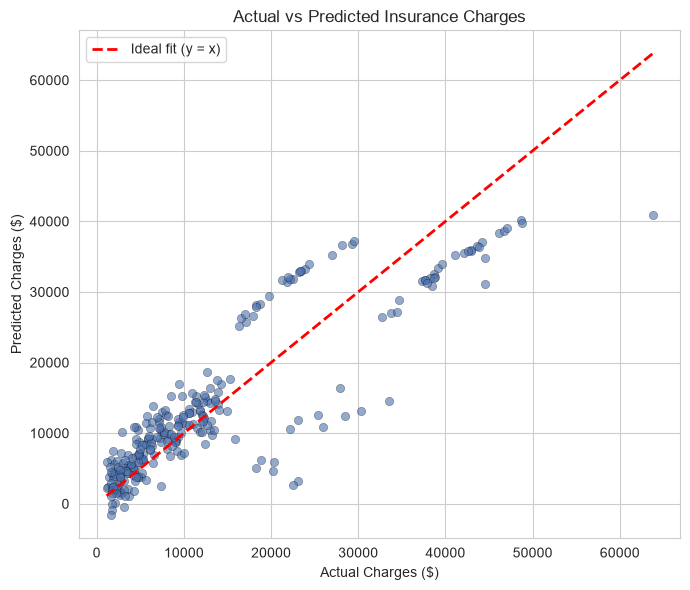

In [16]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#4C72B0', edgecolor='k', linewidth=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Ideal fit (y = x)')
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

**Observations**

1. The model achieves an R² score of **~0.78**,so it explains about 78% of our variance
   in medical insurance charges using only six input features.
2. `smoker` has by far the largest coefficient (~+23,650), hence it is the single strongest
   driver of insurance cost — smokers are charged way more than non-smokers, all else equal.
3. The scatter plot shows two loose "bands" of points rather than a single tight line around the
   ideal-fit line. This reflects the smoker/non-smoker split in the data — linear regression fits
   a single global trend, so it underpredicts charges for high-cost smokers and slightly overpredicts
   for some low-cost non-smokers, which also explains the relatively high MAE/RMSE despite a
   reasonable R².

## Task 5: Conclusion

This project applied Multiple Linear Regression to predict medical insurance charges from six
personal and health-related attributes. The model explained roughly 78% of the variance in
charges (R² ≈ 0.78) on unseen test data, with an average prediction error (MAE) of about
$4,180. Among all predictors, **smoking status** emerged as the dominant factor, adding over
$23,000 to predicted charges on average, far outweighing the effects of age, BMI, number of
children, sex, or region. Age and BMI also contributed positively but much more modestly. A key
limitation of Linear Regression here is its assumption of a purely additive, linear relationship
between features and cost: in reality, smoking interacts strongly with BMI and age (e.g., obese
smokers incur disproportionately higher charges).